# FBA Model Validation: Phenotype Microarray Scoring with MCC

> **Note:** This notebook reproduces the validation workflow originally developed in MATLAB for the *Dunaliella salina* genome-scale metabolic model `iDunsR`. Because the model is unpublished, the workflow is demonstrated using the **E. coli core model** with synthetic Biolog-style phenotype data. All logic, metrics, and visualizations are directly transferable to `iDunsR`.

---

## Background: Why Validate a Metabolic Model?

A genome-scale metabolic model (GEM) is only useful if its predictions match experimental reality. **Phenotype Microarray (PM) assays** (Biolog plates) provide a systematic way to test this: each well contains a different carbon or nitrogen source, and growth (or lack thereof) is measured. If the model predicts growth on a substrate the organism can't actually use — or vice versa — there's a gap in the model's curation.

### What is MCC?

The **Matthews Correlation Coefficient (MCC)** is a single number summarizing how well binary predictions (growth / no-growth) match experiments:

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

| Value | Meaning |
|---|---|
| +1 | Perfect prediction |
| 0 | No better than random |
| −1 | Perfectly wrong |

MCC is preferred over accuracy for imbalanced datasets — if 90% of substrates support no growth, a model that always predicts no-growth achieves 90% accuracy but MCC ≈ 0.

## Workflow

For each substrate in the PM data:
1. Check whether the model has an exchange reaction for it
2. If yes: set the default carbon/nitrogen source uptake to 0, open the test substrate, run FBA
3. Classify the result as TP / TN / FP / FN by comparing predicted vs. experimental growth
4. Compute MCC separately for carbon sources (PM1/PM2 plates) and nitrogen sources (PM3+ plates)


In [1]:
# ── Dependencies ───────────────────────────────────────────────────────────────
# pip install cobra numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cobra
from cobra.io import load_model
import warnings
warnings.filterwarnings('ignore')

print(f"COBRApy version: {cobra.__version__}")

COBRApy version: 0.27.0


## 1. Load Model

In [2]:
# ── Load proxy model ───────────────────────────────────────────────────────────
# Replace with: model = cobra.io.read_sbml_model('iDunsR.xml')
# The default carbon source in iDunsR was bicarbonate (EX_hco3_e)
# and default nitrogen source was nitrate (EX_no3_e).
# Here we use glucose/ammonium as the E. coli core equivalents.

model = load_model('e_coli_core')

DEFAULT_C_SOURCE = 'EX_glc__D_e'   # iDunsR: 'EX_hco3_e' (bicarbonate)
DEFAULT_N_SOURCE = 'EX_nh4_e'      # iDunsR: 'EX_no3_e'  (nitrate)

print(f"Model loaded: {model.id}")
print(f"  Reactions  : {len(model.reactions)}")
print(f"  Metabolites: {len(model.metabolites)}")
print(f"  Genes      : {len(model.genes)}")

# Baseline growth
baseline = model.optimize().objective_value
print(f"  Baseline growth rate: {baseline:.4f} h⁻¹")

Output()

Model loaded: e_coli_core
  Reactions  : 95
  Metabolites: 72
  Genes      : 137
  Baseline growth rate: 0.8739 h⁻¹


## 2. Phenotype Microarray Data

In the original study, PM data came from Biolog plates tested on *Dunaliella salina*. Each row contains:
- The plate ID (`PM1`/`PM2` = carbon sources, `PM3`+ = nitrogen sources)
- The metabolite BiGG ID (used to find the exchange reaction `EX_{met}_e`)
- The experimental result (`+` = growth observed, `-` = no growth)

Below we generate representative synthetic data using exchange reactions that exist in the E. coli core model.

In [3]:
# ── Build synthetic PM dataset from model exchange reactions ───────────────────
# In the real workflow this was loaded from an Excel/CSV file of Biolog results.

np.random.seed(42)

# Collect exchange reactions (excluding the defaults)
exchange_rxns = [
    r for r in model.exchanges
    if r.id not in {DEFAULT_C_SOURCE, DEFAULT_N_SOURCE,
                    'EX_o2_e', 'EX_co2_e', 'EX_h2o_e', 'EX_h_e', 'EX_pi_e'}
]

# Split roughly into carbon vs nitrogen PM plates
c_rxns = exchange_rxns[:len(exchange_rxns)//2]
n_rxns = exchange_rxns[len(exchange_rxns)//2:]

def make_pm_rows(rxns, plate_prefix, n_source_flag):
    rows = []
    for rxn in rxns:
        met_id = rxn.id.replace('EX_', '').replace('_e', '')
        # Simulate experimental result: ~60% positive for C sources, ~40% for N
        p_growth = 0.60 if not n_source_flag else 0.40
        exp = '+' if np.random.random() < p_growth else '-'
        rows.append({
            'plate':      plate_prefix,
            'met_id':     met_id,
            'rxn_id':     rxn.id,
            'experiment': exp,
            'is_nitrogen': n_source_flag,
        })
    return rows

pm_data = pd.DataFrame(
    make_pm_rows(c_rxns, 'PM1', False) +
    make_pm_rows(n_rxns, 'PM3', True)
)

print(f"PM dataset: {len(pm_data)} substrates")
print(f"  Carbon source tests  : {(~pm_data.is_nitrogen).sum()}")
print(f"  Nitrogen source tests: {pm_data.is_nitrogen.sum()}")
print()
print(pm_data.head(8).to_string(index=False))

PM dataset: 13 substrates
  Carbon source tests  : 6
  Nitrogen source tests: 7

plate met_id      rxn_id experiment  is_nitrogen
  PM1     ac     EX_ac_e          +        False
  PM1  acald  EX_acald_e          -        False
  PM1    akg    EX_akg_e          -        False
  PM1   etoh   EX_etoh_e          +        False
  PM1    for    EX_for_e          +        False
  PM1    fru    EX_fru_e          +        False
  PM3    fum    EX_fum_e          +         True
  PM3 gln__L EX_gln__L_e          -         True


## 3. Run FBA Validation

For each substrate we:
1. Look up its exchange reaction in the model
2. Zero out the default C or N source, open the test substrate
3. Run FBA and classify the outcome

This directly mirrors `testMCC_FBA.m` — the core loop that drove model curation in the original study.

In [4]:
def run_pm_validation(model, pm_data, default_c, default_n,
                      uptake_rate=-5.0, growth_threshold=1e-6):
    """
    Run FBA-based Biolog PM validation.

    For each substrate in pm_data:
    - Carbon source test (PM1/PM2): zero out default C, open test metabolite
    - Nitrogen source test (PM3+) : zero out default N, open test metabolite
    - Classify as TP/TN/FP/FN vs experimental result

    Parameters
    ----------
    model            : COBRApy model
    pm_data          : DataFrame with columns [plate, met_id, rxn_id, experiment, is_nitrogen]
    default_c        : exchange reaction ID for default carbon source
    default_n        : exchange reaction ID for default nitrogen source
    uptake_rate      : lower bound for test substrate (negative = uptake)
    growth_threshold : minimum objective value to call growth positive

    Returns
    -------
    DataFrame with FBA results and classification
    """
    results = []

    for _, row in pm_data.iterrows():
        rxn_id = row['rxn_id']
        exp    = row['experiment']

        # Check exchange reaction exists in model
        if rxn_id not in [r.id for r in model.reactions]:
            results.append({**row,
                'in_model':    False,
                'fba_growth':  None,
                'prediction':  'No exchange rxn',
                'outcome':     'Missing',
            })
            continue

        # Run FBA in a context manager so bounds revert after each test
        with model:
            if not row['is_nitrogen']:
                # Carbon source test: zero default C, open test met
                model.reactions.get_by_id(default_c).lower_bound = 0
                model.reactions.get_by_id(default_n).lower_bound = uptake_rate
            else:
                # Nitrogen source test: zero default N, open test met
                model.reactions.get_by_id(default_c).lower_bound = uptake_rate
                model.reactions.get_by_id(default_n).lower_bound = 0

            model.reactions.get_by_id(rxn_id).lower_bound = uptake_rate
            sol = model.optimize()
            growth = sol.objective_value if sol.status == 'optimal' else 0.0

        predicted_growth = growth > growth_threshold
        experimental_growth = exp == '+'

        if predicted_growth and experimental_growth:     outcome = 'TP'
        elif predicted_growth and not experimental_growth: outcome = 'FP'
        elif not predicted_growth and experimental_growth: outcome = 'FN'
        else:                                              outcome = 'TN'

        results.append({**row,
            'in_model':   True,
            'fba_growth': round(growth, 6),
            'prediction': '+' if predicted_growth else '-',
            'outcome':    outcome,
        })

    return pd.DataFrame(results)


results_df = run_pm_validation(model, pm_data, DEFAULT_C_SOURCE, DEFAULT_N_SOURCE)
print(f"Validation complete: {len(results_df)} substrates tested")
print(results_df[results_df.in_model][['plate','met_id','experiment','prediction','outcome','fba_growth']]
      .head(12).to_string(index=False))

Validation complete: 13 substrates tested
plate met_id experiment prediction outcome  fba_growth
  PM1     ac          +          +      TP    0.065351
  PM1  acald          -          +      FP    0.122521
  PM1    akg          -          +      FP    0.243334
  PM1   etoh          +          +      TP    0.145854
  PM1    for          +          -      FN    0.000000
  PM1    fru          +          +      TP    0.415598
  PM3    fum          +          -      FN    0.000000
  PM3 gln__L          -          +      FP    0.730088
  PM3 glu__L          -          +      FP    0.748435
  PM3 lac__D          -          -      TN    0.000000
  PM3 mal__L          +          -      FN    0.000000
  PM3    pyr          -          -      TN    0.000000


## 4. Compute MCC and Accuracy

MCC is computed three ways — overall, carbon sources only, and nitrogen sources only — matching the breakdown in the original `testMCC_FBA.m`.

In [5]:
def compute_mcc(tp, tn, fp, fn):
    """
    Matthews Correlation Coefficient.
    Returns 0 when denominator is zero (no predictions of one class).
    """
    numerator = (tp * tn) - (fp * fn)
    if numerator == 0:
        return 0.0
    denominator = np.sqrt((tp+fp) * (tp+fn) * (tn+fp) * (tn+fn))
    return numerator / denominator if denominator > 0 else 0.0


def score_subset(df, label):
    """Compute TP/TN/FP/FN/Accuracy/MCC for a subset of results."""
    valid = df[df.outcome.isin(['TP','TN','FP','FN'])]
    tp = (valid.outcome == 'TP').sum()
    tn = (valid.outcome == 'TN').sum()
    fp = (valid.outcome == 'FP').sum()
    fn = (valid.outcome == 'FN').sum()
    total    = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    mcc      = compute_mcc(tp, tn, fp, fn)
    return {'Subset': label, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Total': total, 'Accuracy': round(accuracy, 4), 'MCC': round(mcc, 4)}


summary = pd.DataFrame([
    score_subset(results_df,                                  'General'),
    score_subset(results_df[~results_df.is_nitrogen],         'Carbon Sources'),
    score_subset(results_df[results_df.is_nitrogen],          'Nitrogen Sources'),
]).set_index('Subset')

print("\n" + "="*65)
print("  MCC Validation Summary")
print("="*65)
print(summary.to_string())
print()
print("MCC interpretation: >0.5 = good, >0.7 = strong, 1.0 = perfect")


  MCC Validation Summary
                  TP  TN  FP  FN  Total  Accuracy     MCC
Subset                                                   
General            3   3   4   3     13    0.4615 -0.0714
Carbon Sources     3   0   2   1      6    0.5000 -0.3162
Nitrogen Sources   0   3   2   2      7    0.4286 -0.4000

MCC interpretation: >0.5 = good, >0.7 = strong, 1.0 = perfect


## 5. Visualizations

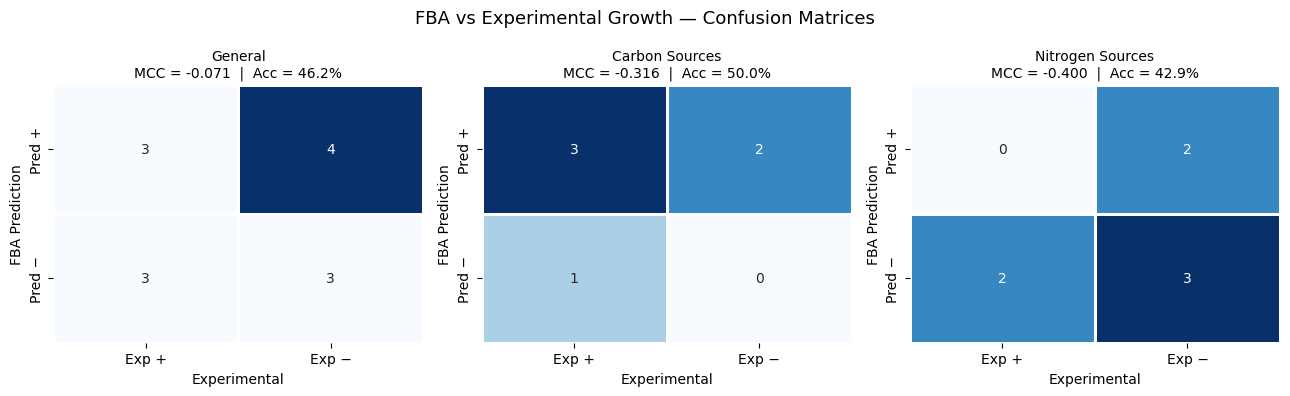

In [7]:
# ── Plot 1: Confusion matrix heatmaps ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('FBA vs Experimental Growth — Confusion Matrices', fontsize=13)

subsets = [
    ('General',          results_df),
    ('Carbon Sources',   results_df[~results_df.is_nitrogen]),
    ('Nitrogen Sources', results_df[results_df.is_nitrogen]),
]

for ax, (label, df) in zip(axes, subsets):
    valid = df[df.outcome.isin(['TP','TN','FP','FN'])]
    # Build 2×2 matrix: rows = predicted, cols = experimental
    mat = np.array([
        [(valid.outcome=='TP').sum(), (valid.outcome=='FP').sum()],
        [(valid.outcome=='FN').sum(), (valid.outcome=='TN').sum()],
    ])
    mcc_val = summary.loc[label, 'MCC']
    acc_val = summary.loc[label, 'Accuracy']

    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Exp +', 'Exp −'],
                yticklabels=['Pred +', 'Pred −'],
                cbar=False, linewidths=1, linecolor='white')
    ax.set_title(f'{label}\nMCC = {mcc_val:.3f}  |  Acc = {acc_val:.1%}', fontsize=10)
    ax.set_xlabel('Experimental')
    ax.set_ylabel('FBA Prediction')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

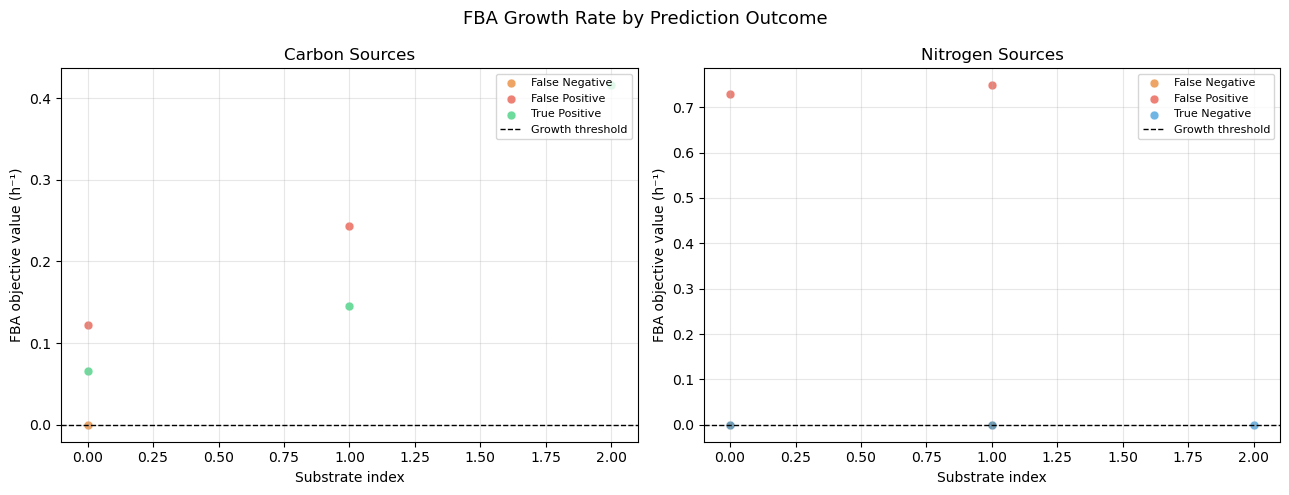

In [9]:
# ── Plot 2: FBA growth rate distribution by outcome ───────────────────────────
# Shows the separation between positive and negative predictions
# and how FBA growth rate relates to classification outcome.

valid = results_df[results_df.outcome.isin(['TP','TN','FP','FN'])].copy()

COLORS = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e74c3c', 'FN': '#e67e22'}
LABELS = {'TP': 'True Positive', 'TN': 'True Negative',
          'FP': 'False Positive', 'FN': 'False Negative'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('FBA Growth Rate by Prediction Outcome', fontsize=13)

for ax, (title, subset) in zip(axes, [
    ('Carbon Sources', valid[~valid.is_nitrogen]),
    ('Nitrogen Sources', valid[valid.is_nitrogen]),
]):
    for outcome, grp in subset.groupby('outcome'):
        ax.scatter(
            range(len(grp)), grp['fba_growth'],
            c=COLORS[outcome], label=LABELS[outcome],
            alpha=0.7, s=40, edgecolors='white', lw=0.4
        )
    ax.axhline(1e-6, color='black', ls='--', lw=1, label='Growth threshold')
    ax.set_xlabel('Substrate index')
    ax.set_ylabel('FBA objective value (h⁻¹)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('growth_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

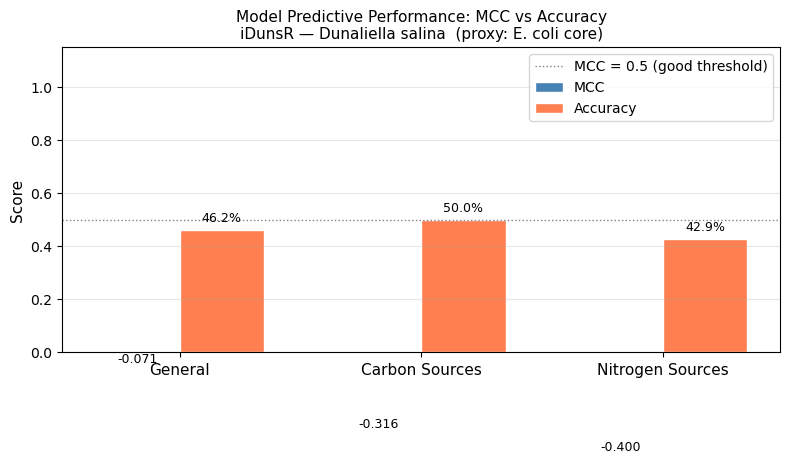

In [11]:
# ── Plot 3: MCC bar chart with accuracy overlay ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x      = np.arange(len(summary))
width  = 0.35
mcc_vals = summary['MCC'].values
acc_vals = summary['Accuracy'].values

bars1 = ax.bar(x - width/2, mcc_vals, width,
               label='MCC', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, acc_vals, width,
               label='Accuracy', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Predictive Performance: MCC vs Accuracy\n'
             'iDunsR — Dunaliella salina  (proxy: E. coli core)', fontsize=11)
ax.axhline(0.5, color='gray', ls=':', lw=1, label='MCC = 0.5 (good threshold)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('mcc_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

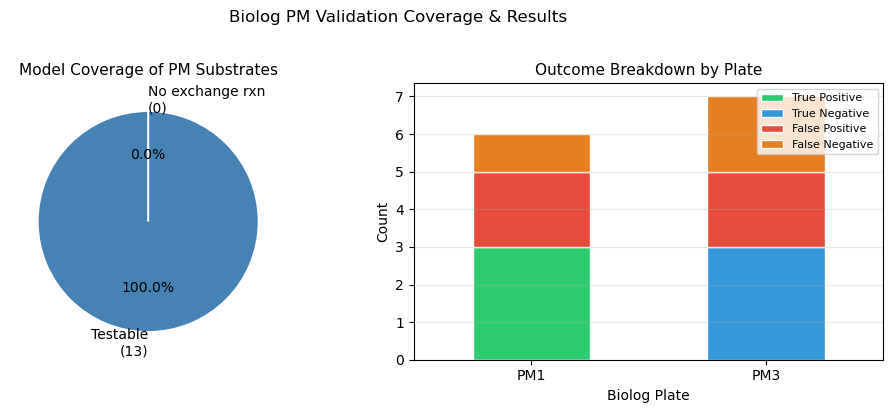

In [13]:
# ── Plot 4: Missing exchange reactions ────────────────────────────────────────
# Substrates with no exchange reaction are model gaps — important for curation.
# In the original study these were flagged for manual gap-filling.

missing = results_df[results_df.outcome == 'Missing']
testable = results_df[results_df.outcome != 'Missing']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie: testable vs missing
axes[0].pie(
    [len(testable), len(missing)],
    labels=[f'Testable\n({len(testable)})', f'No exchange rxn\n({len(missing)})'],
    colors=['steelblue', 'lightcoral'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Model Coverage of PM Substrates', fontsize=11)

# Stacked bar: outcome breakdown by plate
outcome_by_plate = (
    testable[testable.outcome.isin(['TP','TN','FP','FN'])]
    .groupby(['plate','outcome'])
    .size()
    .unstack(fill_value=0)
)
outcome_by_plate[['TP','TN','FP','FN']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[COLORS[c] for c in ['TP','TN','FP','FN']],
    edgecolor='white'
)
axes[1].set_title('Outcome Breakdown by Plate', fontsize=11)
axes[1].set_xlabel('Biolog Plate')
axes[1].set_ylabel('Count')
axes[1].legend([LABELS[c] for c in ['TP','TN','FP','FN']], fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Biolog PM Validation Coverage & Results', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pm_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Full Results Table

In [15]:
# ── Export full results ────────────────────────────────────────────────────────
output_cols = ['plate', 'met_id', 'experiment', 'prediction', 'outcome',
               'fba_growth', 'in_model', 'is_nitrogen']

display_df = results_df[output_cols].copy()
display_df.columns = ['Plate', 'Metabolite', 'Experimental',
                      'FBA Prediction', 'Outcome', 'FBA Growth',
                      'In Model', 'Nitrogen Test']

# Color-code outcome for display
print(display_df.to_string(index=False, max_rows=30))

# Save to CSV for further analysis
display_df.to_csv('pm_validation_results.csv', index=False)
print("\nFull results saved to pm_validation_results.csv")

Plate Metabolite Experimental FBA Prediction Outcome  FBA Growth  In Model  Nitrogen Test
  PM1         ac            +              +      TP    0.065351      True          False
  PM1      acald            -              +      FP    0.122521      True          False
  PM1        akg            -              +      FP    0.243334      True          False
  PM1       etoh            +              +      TP    0.145854      True          False
  PM1        for            +              -      FN    0.000000      True          False
  PM1        fru            +              +      TP    0.415598      True          False
  PM3        fum            +              -      FN    0.000000      True           True
  PM3     gln__L            -              +      FP    0.730088      True           True
  PM3     glu__L            -              +      FP    0.748435      True           True
  PM3     lac__D            -              -      TN    0.000000      True           True
  PM3     

## Summary

| Step | Method | Output |
|---|---|---|
| Substrate lookup | Exchange reaction ID matching | In-model vs missing substrates |
| FBA simulation | COBRApy `optimize()` with bound manipulation | Growth rate per substrate |
| Classification | Growth threshold `> 1e-6 h⁻¹` | TP / TN / FP / FN |
| Model scoring | MCC + Accuracy | Per-subset performance table |
| Visualization | Confusion matrices, scatter, bar, pie | Four diagnostic plots |

### Why MCC over Accuracy?
PM datasets are typically imbalanced — most substrates don't support growth. A model that simply predicts no-growth for everything would achieve high accuracy but MCC ≈ 0. MCC penalizes both false positives (model predicts growth where there is none — model too permissive) and false negatives (model misses real growth — model too restrictive), making it the right metric for model curation.

### Reproducibility note
To run with the actual `iDunsR` model and real Biolog data:
```python
model    = cobra.io.read_sbml_model('iDunsR.xml')
pm_data  = pd.read_csv('biolog_data.csv')   # columns: plate, met_id, rxn_id, experiment
results  = run_pm_validation(model, pm_data, 'EX_hco3_e', 'EX_no3_e')
```